# Mozilla Common Voice (en-AU) — Feature Analysis for Speaker Verification

This notebook analyses acoustic and metadata features of the Mozilla Common Voice Australian English dataset to identify characteristics that discriminate between speakers — the foundation of a speaker verification system.

**Goal:** determine which acoustic features are most stable within a speaker and most variable across speakers, making them useful for "is this person who they claim to be?" verification.


In [1]:
# ── 0. Dependencies ──────────────────────────────────────────────────────────
# Uncomment and run once if packages are missing:
# %pip install librosa soundfile pandas numpy matplotlib seaborn scikit-learn tqdm umap-learn

import warnings
warnings.filterwarnings("ignore")

import os, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import librosa
import librosa.display
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR   = pathlib.Path("data/commonvoice-v24_en-AU 3")
AUDIO_DIR  = DATA_DIR / "audio_files"
META_CSV   = DATA_DIR / "commonvoice-v24_en-AU.csv"
SPLIT_CSV  = DATA_DIR / "commonvoice-v24_en-AU-split.csv"

print("Data dir exists:", DATA_DIR.exists())
print("Audio files found:", len(list(AUDIO_DIR.glob("*.mp3"))))


Data dir exists: True
Audio files found: 3952


## 1. Load Metadata & Cross-Reference Available Audio


In [2]:
# Load metadata
df_meta = pd.read_csv(META_CSV, index_col=0)

# Normalise column names
df_meta.columns = df_meta.columns.str.strip()

# Keep only rows whose audio file actually exists on disk
available = {p.name for p in AUDIO_DIR.glob("*.mp3")}
df = df_meta[df_meta["path"].isin(available)].copy()
df["audio_path"] = df["path"].apply(lambda p: str(AUDIO_DIR / p))

# Tidy gender & age labels
df["gender"] = df["gender"].str.replace("_masculine", "").str.replace("_feminine", "")
df["age"]    = df["age"].fillna("unknown")

# Add a numeric speaker index for later modelling helpers
speaker_ids   = df["client_id"].unique()
spk_map       = {sid: i for i, sid in enumerate(speaker_ids)}
df["spk_idx"] = df["client_id"].map(spk_map)

print(f"Total rows with audio on disk : {len(df):,}")
print(f"Unique speakers               : {df['client_id'].nunique():,}")
print(f"Clips per speaker (mean)      : {df.groupby('client_id').size().mean():.1f}")
df.head(3)


Total rows with audio on disk : 3,951
Unique speakers               : 418
Clips per speaker (mean)      : 9.5


,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment,duration_ms,audio_path,spk_idx
2029,47e310af6db6b62e9820ec86ab728d5b5a374e609c86eb...,common_voice_en_42006138.mp3,09366b701c5430420b021acc7d6e5f9a70c7ddf1504ad1...,A healthy diet combined with lots of exercise ...,NaN,2,0,unknown,NaN,"Australian English,Canadian English",NaN,en,NaN,7.495500,data\commonvoice-v24_en-AU 3\audio_files\commo...,0
2786,62d6abcbb95b1bdf7baf814a83dd1c82e73f2557a051ff...,common_voice_en_40773379.mp3,ede07ca01008a5a8a132081def59baa8b72512b0870372...,Kovu returns to Pride Rock to plead Simba for ...,NaN,2,0,fourties,NaN,Australian English,NaN,en,NaN,7.855500,data\commonvoice-v24_en-AU 3\audio_files\commo...,1
2845,64eec0ce74775025119b960ed846dc68b1bd6bbb6a71e5...,common_voice_en_23774819.mp3,73fc94f7cb1222a49f37d9e9b80cdf85025d638136897c...,The major part of its funding derives from thi...,NaN,2,0,thirties,male,Australian English,NaN,en,NaN,6.509625,data\commonvoice-v24_en-AU 3\audio_files\commo...,2


## 2. Metadata EDA — Who is in the Dataset?


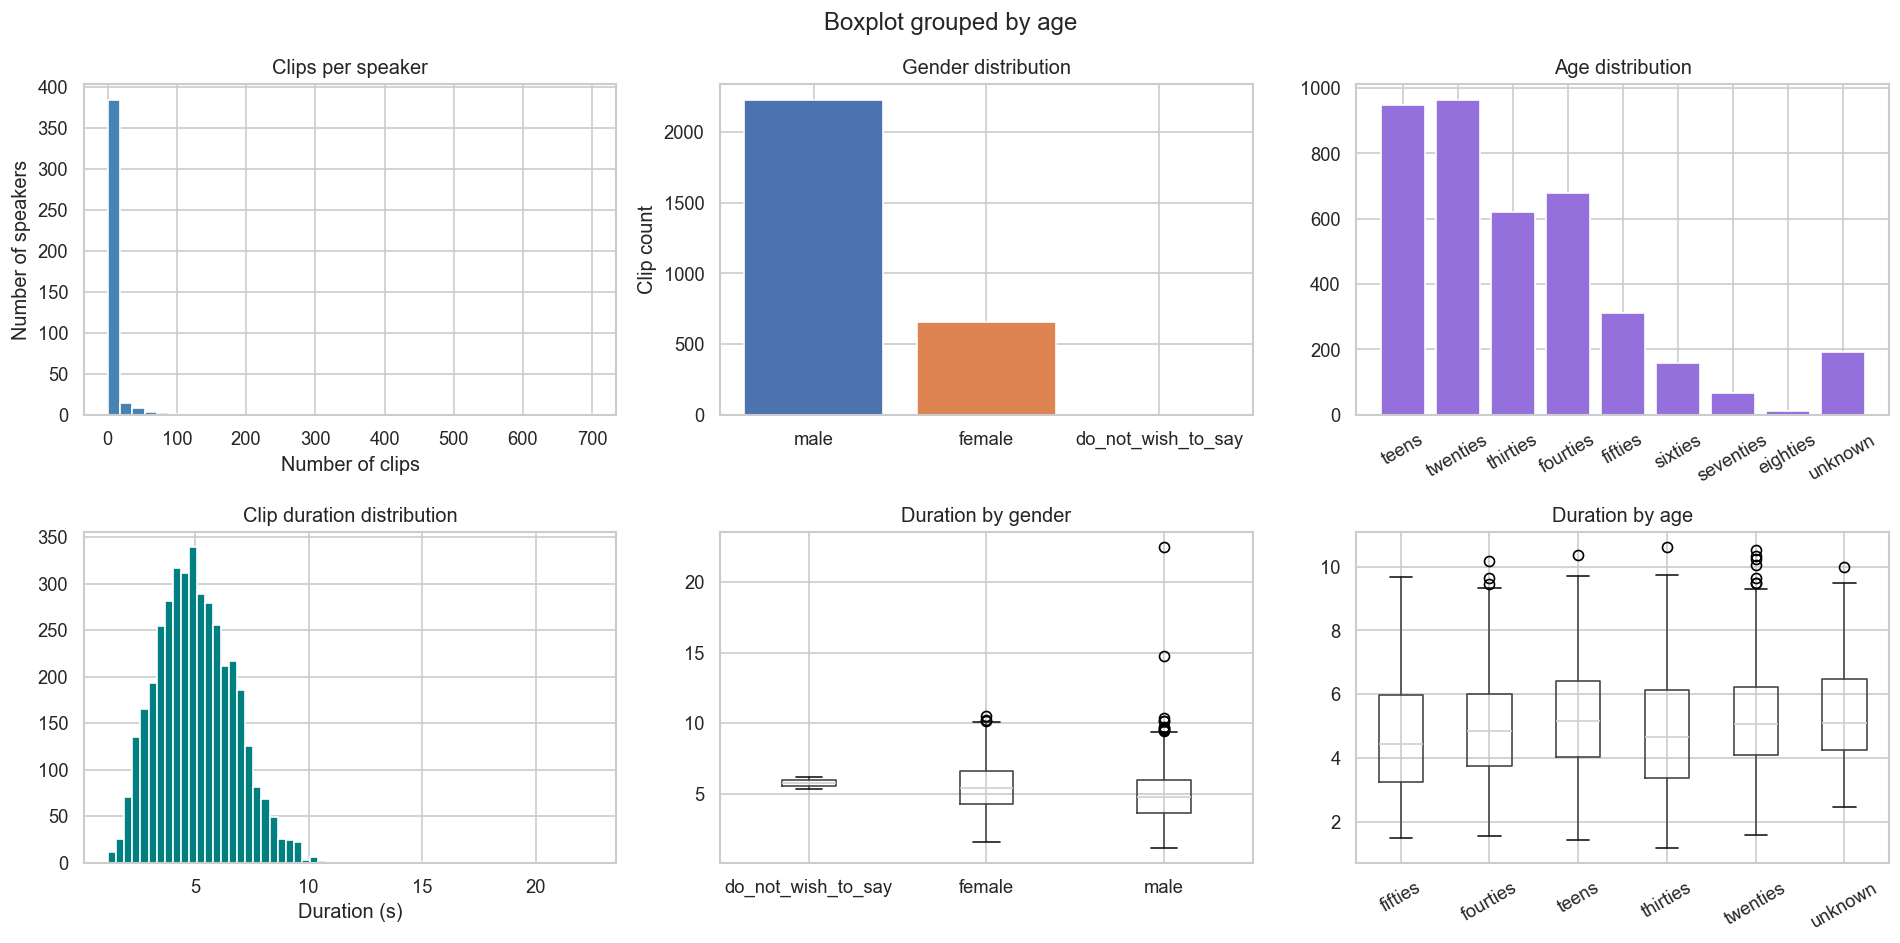


Speaker clip count summary:
count    418.00
mean       9.45
std       38.96
min        1.00
25%        2.00
50%        3.00
75%        6.00
max      700.00
dtype: float64


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Dataset Overview — Mozilla Common Voice en-AU (available audio)", fontsize=14, y=1.01)

# 1. Clips per speaker distribution
clips_per_spk = df.groupby("client_id").size()
axes[0, 0].hist(clips_per_spk, bins=40, color="steelblue", edgecolor="white")
axes[0, 0].set_xlabel("Number of clips")
axes[0, 0].set_ylabel("Number of speakers")
axes[0, 0].set_title("Clips per speaker")

# 2. Gender breakdown
gender_counts = df["gender"].value_counts()
axes[0, 1].bar(gender_counts.index, gender_counts.values, color=["#4C72B0", "#DD8452", "#55A868"])
axes[0, 1].set_title("Gender distribution")
axes[0, 1].set_ylabel("Clip count")

# 3. Age breakdown
age_order = ["teens", "twenties", "thirties", "fourties", "fifties", "sixties", "seventies", "eighties", "unknown"]
age_counts = df["age"].value_counts().reindex([a for a in age_order if a in df["age"].values])
axes[0, 2].bar(age_counts.index, age_counts.values, color="mediumpurple")
axes[0, 2].set_title("Age distribution")
axes[0, 2].tick_params(axis="x", rotation=30)

# 4. Duration distribution (seconds — column is labelled ms but values look like seconds)
axes[1, 0].hist(df["duration_ms"], bins=60, color="teal", edgecolor="white")
axes[1, 0].set_xlabel("Duration (s)")
axes[1, 0].set_title("Clip duration distribution")

# 5. Duration by gender (box)
df.boxplot(column="duration_ms", by="gender", ax=axes[1, 1])
axes[1, 1].set_title("Duration by gender")
axes[1, 1].set_xlabel("")
plt.sca(axes[1, 1])
plt.title("Duration by gender")

# 6. Duration by age (box) — top 6 age groups
top_ages = df["age"].value_counts().head(6).index
df[df["age"].isin(top_ages)].boxplot(column="duration_ms", by="age", ax=axes[1, 2])
axes[1, 2].set_title("Duration by age")
axes[1, 2].set_xlabel("")
axes[1, 2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("\nSpeaker clip count summary:")
print(clips_per_spk.describe().round(2))


## 3. Audio Feature Extraction

For each clip we extract a compact summary vector of acoustic features that are well-established in speaker recognition research:

| Feature group | What it captures |
|---|---|
| **MFCCs** (mean + std, 13 coefficients) | Vocal tract shape — the most speaker-discriminative features |
| **Pitch / F0** (mean, std, voiced ratio) | Fundamental frequency — varies significantly across speakers |
| **Spectral centroid / bandwidth / rolloff** | Timbral brightness & energy distribution |
| **ZCR** | Noisiness / fricative character of voice |
| **RMS energy** | Overall loudness |
| **Chroma** | Harmonic content |

Processing is cached to a CSV so it only runs once.


In [4]:
FEATURE_CACHE = pathlib.Path("data/feature_cache_mozilla.csv")

N_MFCC   = 13
SR_TARGET = 22050  # resample target

def extract_features(path: str) -> dict | None:
    """Return a flat feature dict for one audio file, or None on error."""
    try:
        y, sr = librosa.load(path, sr=SR_TARGET, mono=True)
        if len(y) < SR_TARGET * 0.3:   # skip clips shorter than 0.3 s
            return None

        feats = {}

        # ── MFCCs ──────────────────────────────────────────────────────────
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
        for i in range(N_MFCC):
            feats[f"mfcc{i+1}_mean"] = float(np.mean(mfcc[i]))
            feats[f"mfcc{i+1}_std"]  = float(np.std(mfcc[i]))

        # ── Pitch (YIN) ────────────────────────────────────────────────────
        f0 = librosa.yin(y, fmin=50, fmax=400, sr=sr)
        voiced = f0[f0 > 0]
        feats["pitch_mean"]       = float(np.mean(voiced))   if len(voiced) > 0 else 0.0
        feats["pitch_std"]        = float(np.std(voiced))    if len(voiced) > 0 else 0.0
        feats["voiced_ratio"]     = float(len(voiced) / len(f0))

        # ── Spectral features ──────────────────────────────────────────────
        cent   = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
        bw     = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
        rolloff= librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
        flatness = librosa.feature.spectral_flatness(y=y)[0]
        feats["spec_centroid_mean"]  = float(np.mean(cent))
        feats["spec_centroid_std"]   = float(np.std(cent))
        feats["spec_bandwidth_mean"] = float(np.mean(bw))
        feats["spec_rolloff_mean"]   = float(np.mean(rolloff))
        feats["spec_flatness_mean"]  = float(np.mean(flatness))

        # ── Zero-Crossing Rate ─────────────────────────────────────────────
        zcr = librosa.feature.zero_crossing_rate(y)[0]
        feats["zcr_mean"] = float(np.mean(zcr))
        feats["zcr_std"]  = float(np.std(zcr))

        # ── RMS Energy ────────────────────────────────────────────────────
        rms = librosa.feature.rms(y=y)[0]
        feats["rms_mean"] = float(np.mean(rms))
        feats["rms_std"]  = float(np.std(rms))

        # ── Chroma ────────────────────────────────────────────────────────
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        feats["chroma_mean"] = float(np.mean(chroma))
        feats["chroma_std"]  = float(np.std(chroma))

        # ── Mel-spectrogram energy bands (4 sub-bands) ────────────────────
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
        mel_db = librosa.power_to_db(mel)
        for b, (lo, hi) in enumerate([(0,16),(16,32),(32,48),(48,64)]):
            feats[f"mel_band{b+1}_mean"] = float(np.mean(mel_db[lo:hi]))

        return feats
    except Exception:
        return None


if FEATURE_CACHE.exists():
    print("Loading cached features …")
    feat_df = pd.read_csv(FEATURE_CACHE)
else:
    print(f"Extracting features for {len(df)} clips … (this may take a few minutes)")
    records = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        feat = extract_features(row["audio_path"])
        if feat is not None:
            feat["path"]      = row["path"]
            feat["client_id"] = row["client_id"]
            feat["spk_idx"]   = row["spk_idx"]
            feat["gender"]    = row["gender"]
            feat["age"]       = row["age"]
            feat["duration"]  = row["duration_ms"]
            records.append(feat)
    feat_df = pd.DataFrame(records)
    feat_df.to_csv(FEATURE_CACHE, index=False)
    print(f"Saved {len(feat_df):,} feature rows to {FEATURE_CACHE}")

# Identify pure numeric feature columns
META_COLS = ["path", "client_id", "spk_idx", "gender", "age", "duration"]
FEAT_COLS = [c for c in feat_df.columns if c not in META_COLS]

print(f"\nFeature vectors: {feat_df.shape}  |  Feature dimensions: {len(FEAT_COLS)}")
feat_df.head(3)


Extracting features for 3951 clips … (this may take a few minutes)


  0%|          | 0/3951 [00:00<?, ?it/s]

Saved 3,951 feature rows to data\feature_cache_mozilla.csv

Feature vectors: (3951, 50)  |  Feature dimensions: 44


,mfcc1_mean,mfcc1_std,mfcc2_mean,mfcc2_std,mfcc3_mean,mfcc3_std,mfcc4_mean,mfcc4_std,mfcc5_mean,mfcc5_std,...,mel_band1_mean,mel_band2_mean,mel_band3_mean,mel_band4_mean,path,client_id,spk_idx,gender,age,duration
0,-384.414032,135.488525,69.643822,77.347618,11.409337,28.327034,13.308999,20.073805,-4.839400,20.678909,...,-23.957561,-32.802437,-38.181362,-42.797329,common_voice_en_42006138.mp3,47e310af6db6b62e9820ec86ab728d5b5a374e609c86eb...,0,NaN,unknown,7.495500
1,-343.852081,136.276108,52.670891,70.540619,4.062130,33.279224,28.712698,29.053625,15.228810,31.497663,...,-20.921074,-30.500776,-30.145630,-36.611416,common_voice_en_40773379.mp3,62d6abcbb95b1bdf7baf814a83dd1c82e73f2557a051ff...,1,NaN,fourties,7.855500
2,-415.165131,132.943985,106.866493,78.418686,10.634172,24.116232,33.359200,26.870108,12.299103,20.759304,...,-21.118525,-35.622185,-41.129356,-51.248665,common_voice_en_23774819.mp3,64eec0ce74775025119b960ed846dc68b1bd6bbb6a71e5...,2,male,thirties,6.509625


## 4. Feature Distribution Analysis


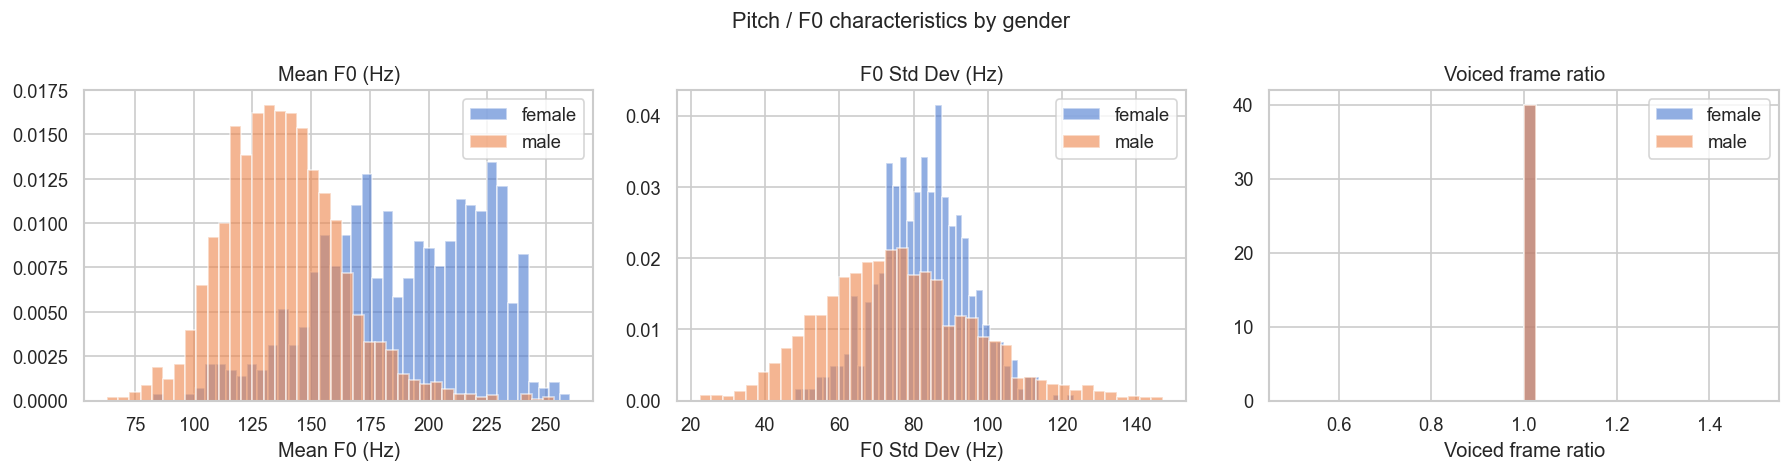

In [5]:
# ── 4a. Pitch distributions by gender ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Pitch / F0 characteristics by gender", fontsize=13)

for ax, col, label in zip(axes,
        ["pitch_mean", "pitch_std", "voiced_ratio"],
        ["Mean F0 (Hz)", "F0 Std Dev (Hz)", "Voiced frame ratio"]):
    for g, grp in feat_df[feat_df["gender"].isin(["male", "female"])].groupby("gender"):
        ax.hist(grp[col].dropna(), bins=40, alpha=0.6, label=g, density=True)
    ax.set_xlabel(label); ax.set_title(label); ax.legend()

plt.tight_layout()
plt.show()


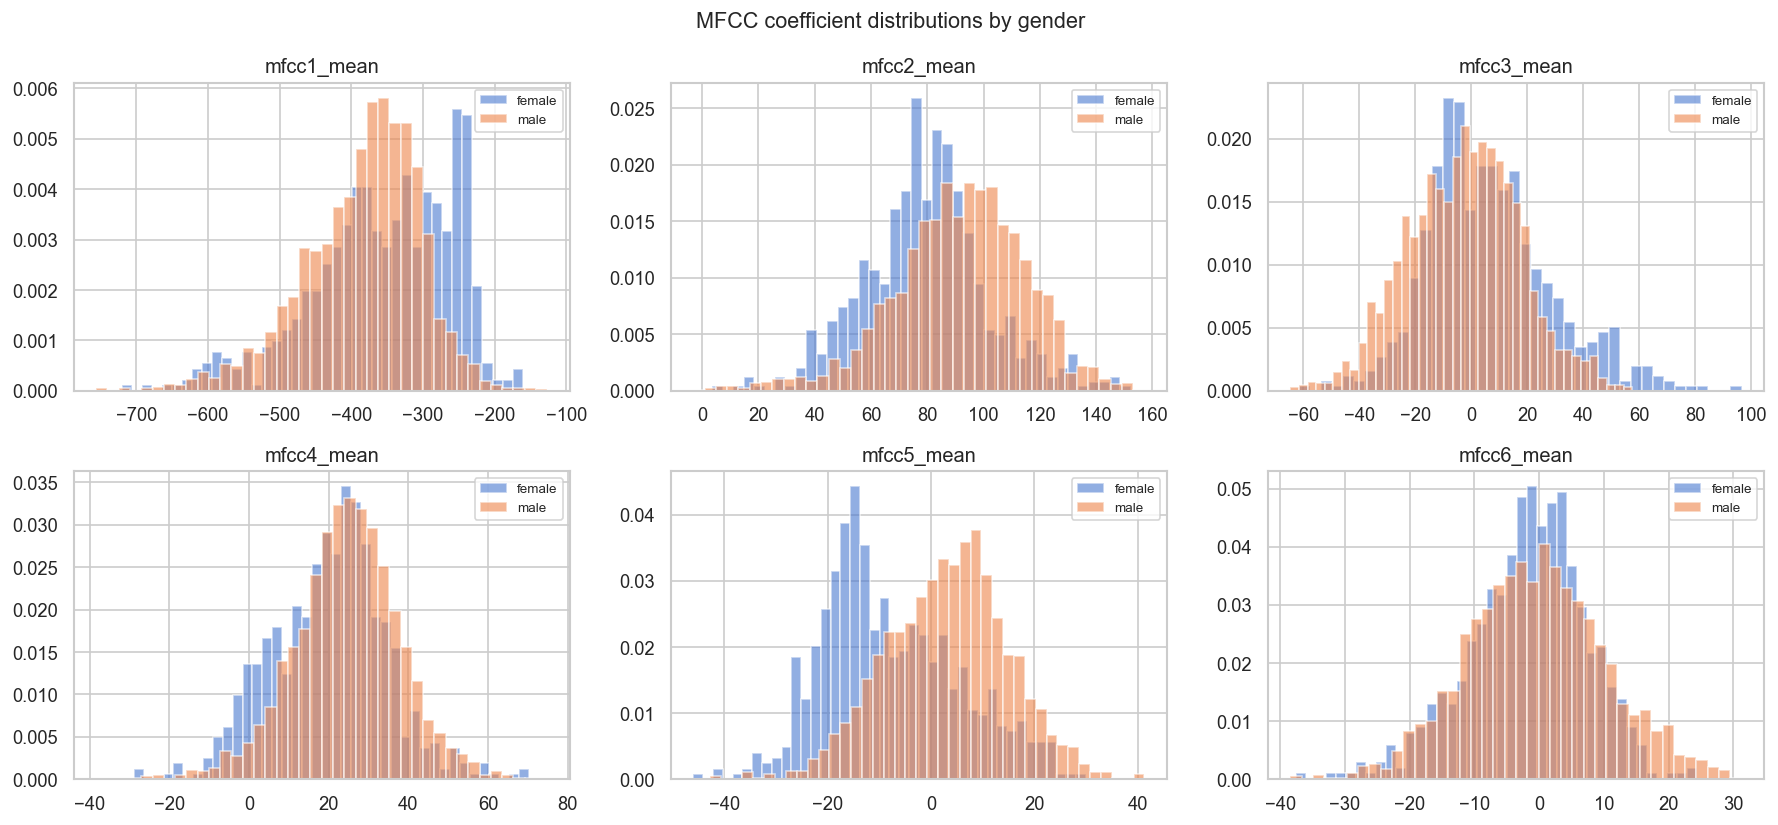

In [6]:
# ── 4b. MFCC mean distributions — first 6 coefficients ──────────────────────
mfcc_mean_cols = [f"mfcc{i}_mean" for i in range(1, 7)]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle("MFCC coefficient distributions by gender", fontsize=13)

for ax, col in zip(axes.flat, mfcc_mean_cols):
    for g, grp in feat_df[feat_df["gender"].isin(["male", "female"])].groupby("gender"):
        ax.hist(grp[col].dropna(), bins=40, alpha=0.6, label=g, density=True)
    ax.set_title(col); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


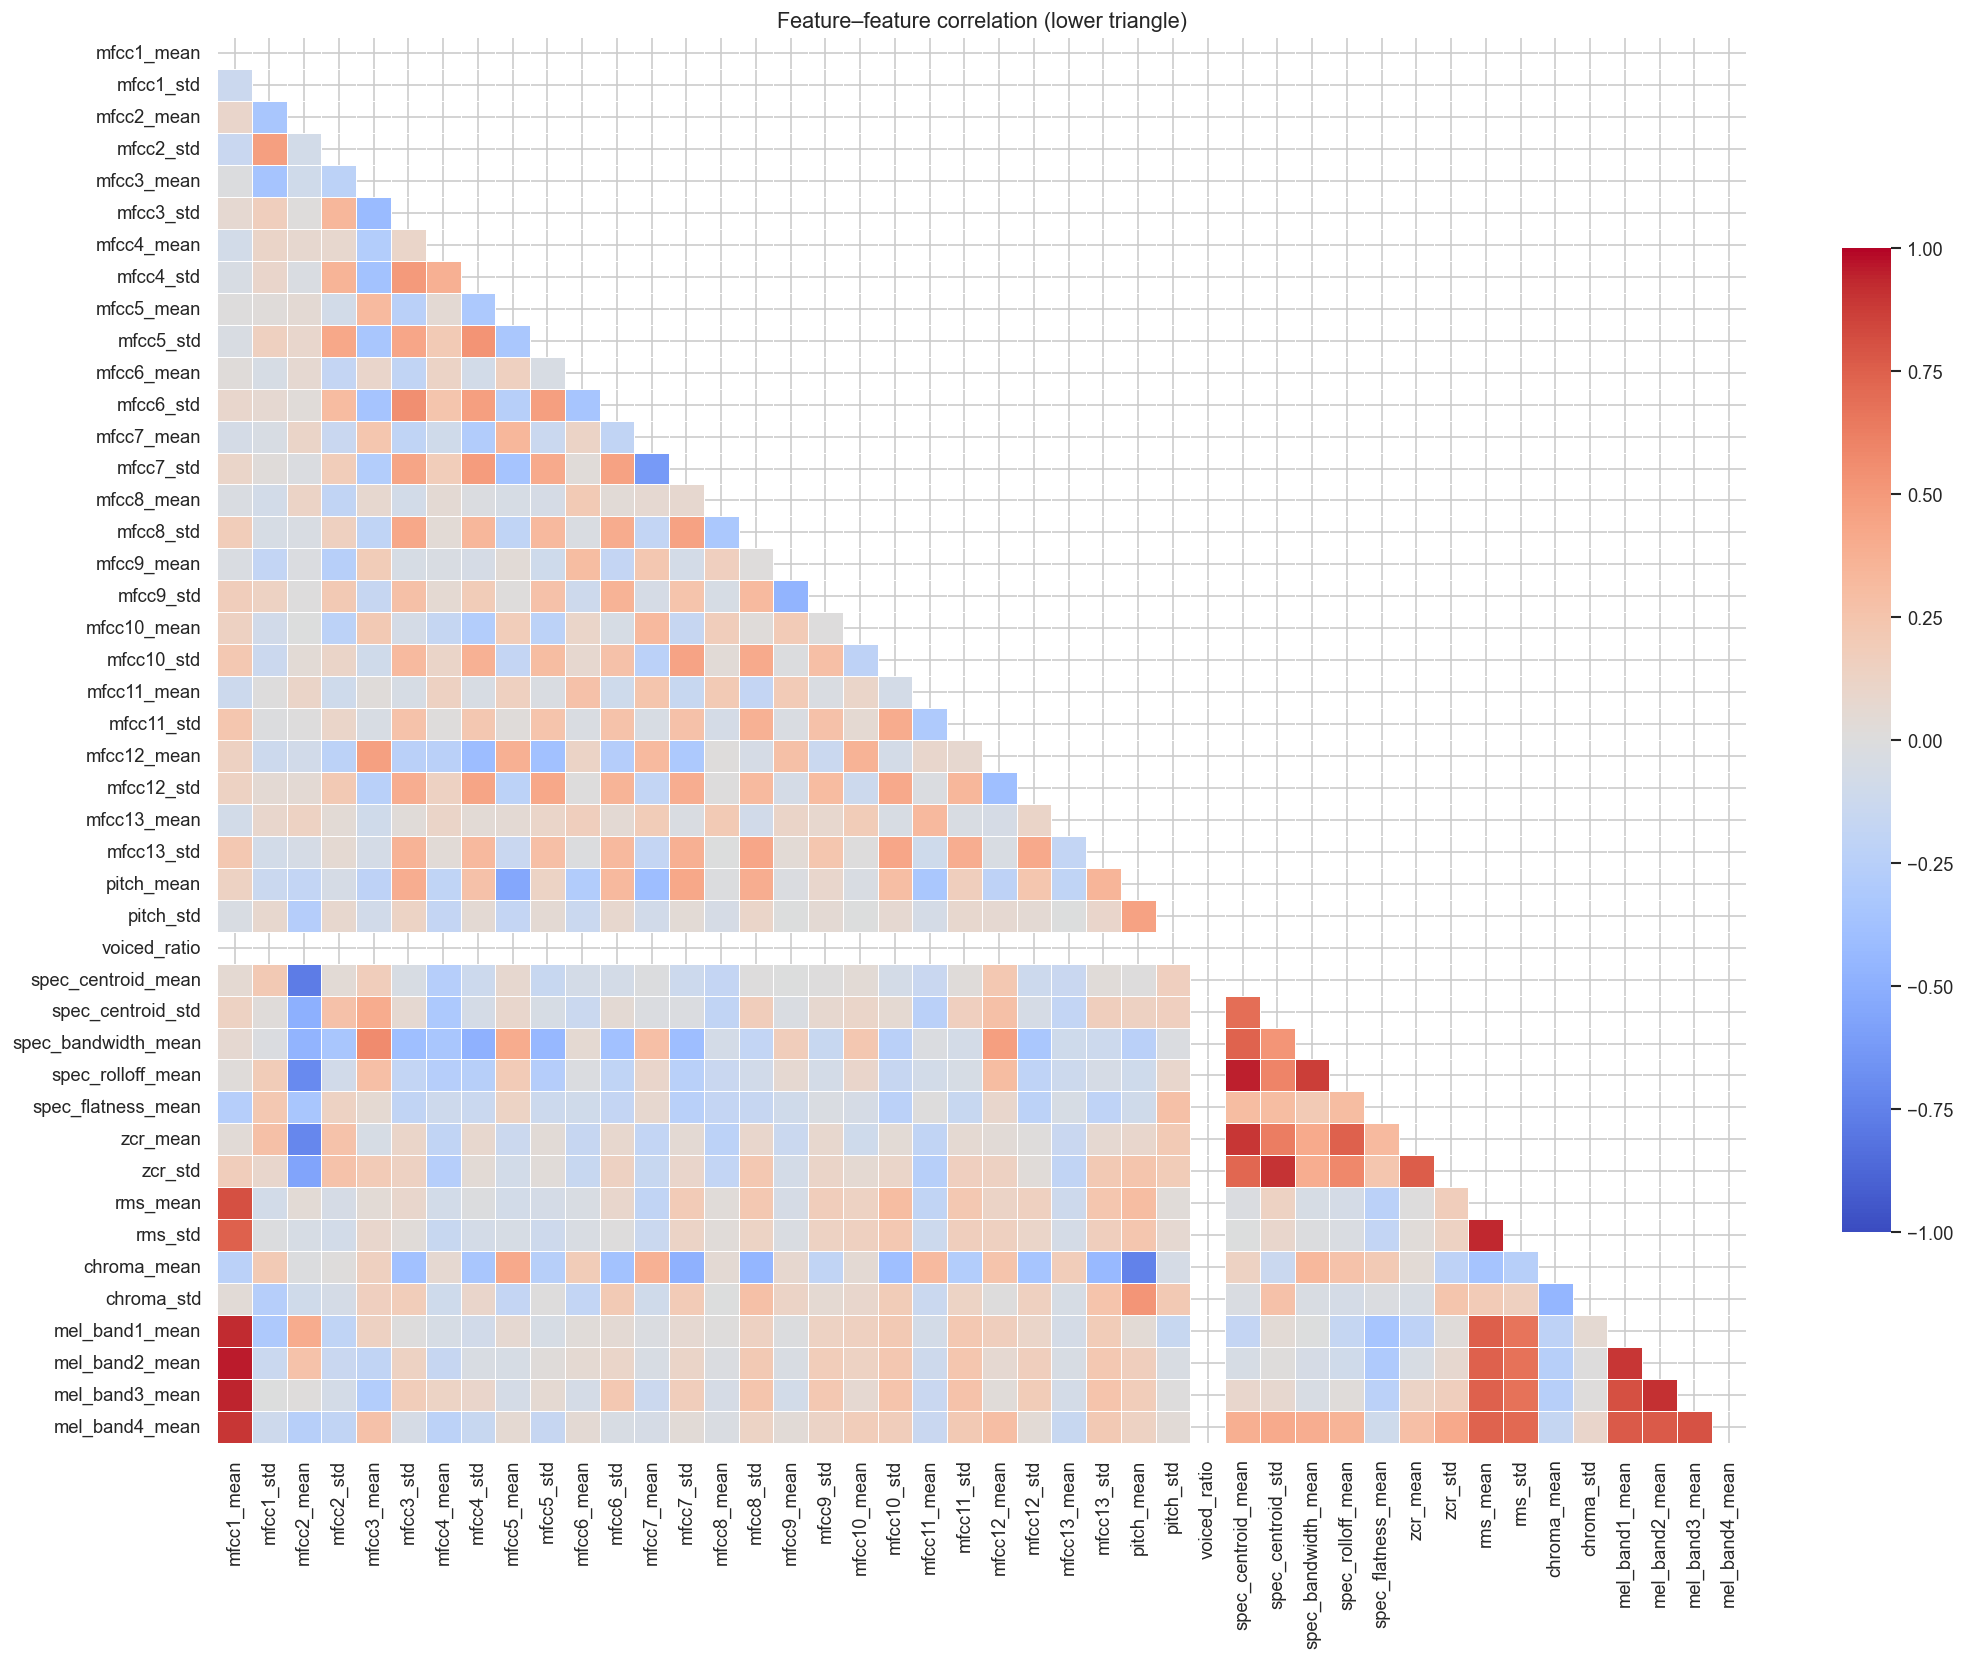

In [7]:
# ── 4c. Correlation heatmap across all features ───────────────────────────────
corr = feat_df[FEAT_COLS].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.3, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Feature–feature correlation (lower triangle)", fontsize=13)
plt.tight_layout()
plt.show()


## 5. Within-Speaker vs. Between-Speaker Variance

The key question for speaker verification: **does a feature vary more *between* speakers than *within* a single speaker?**  
We use the **F-ratio** (between-group variance / within-group variance) — a higher ratio means the feature is more discriminative.


Speakers with ≥3 clips: 235  (3,675 clips)


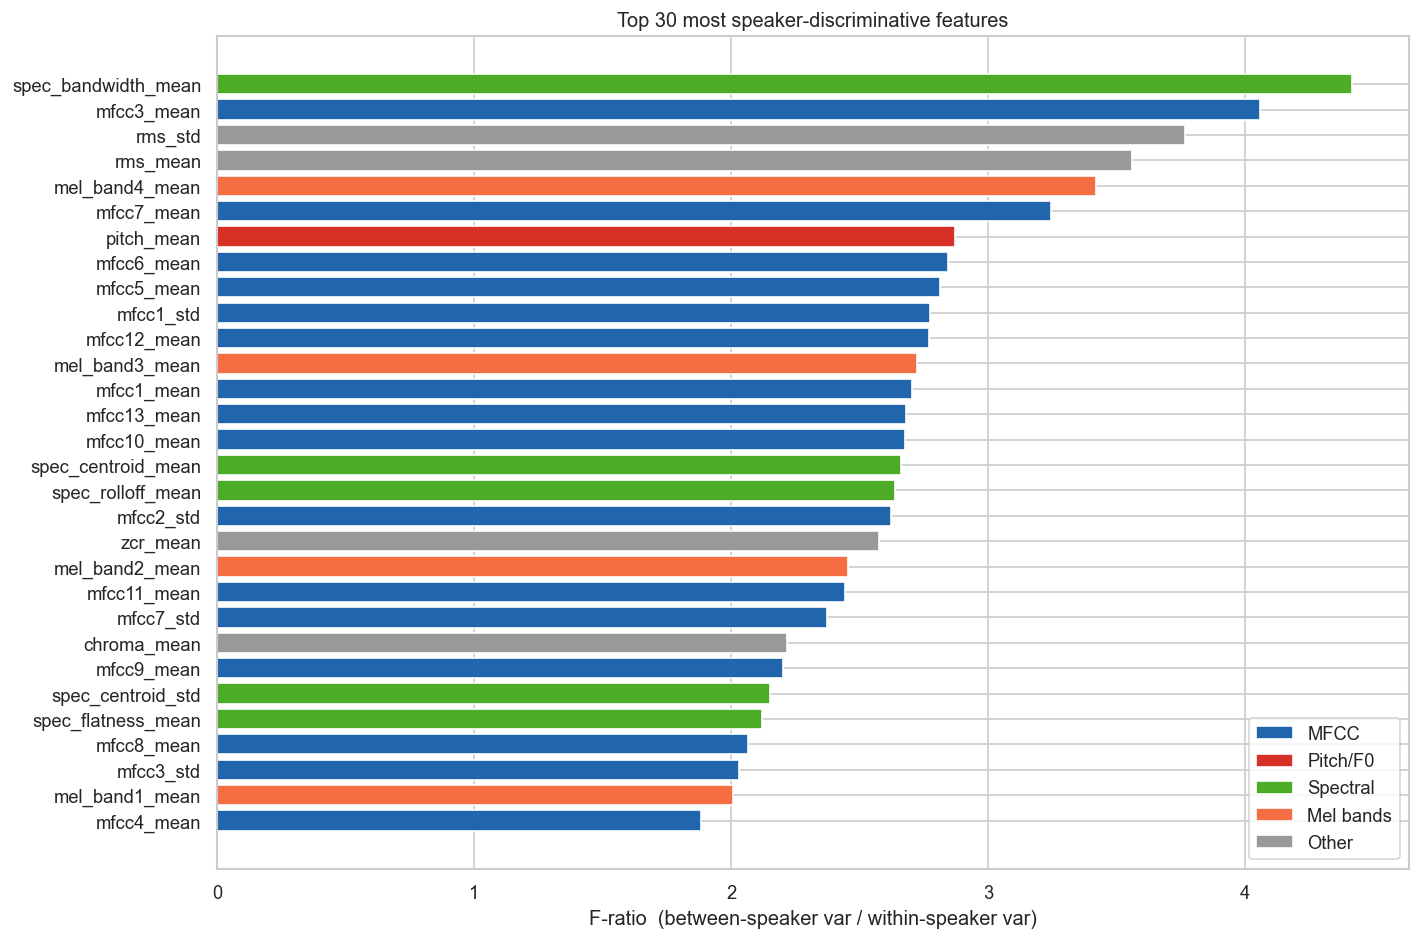


Top 15 features by F-ratio:
spec_bandwidth_mean    4.415
mfcc3_mean             4.057
rms_std                3.763
rms_mean               3.558
mel_band4_mean         3.418
mfcc7_mean             3.245
pitch_mean             2.870
mfcc6_mean             2.844
mfcc5_mean             2.813
mfcc1_std              2.775
mfcc12_mean            2.768
mel_band3_mean         2.724
mfcc1_mean             2.704
mfcc13_mean            2.678
mfcc10_mean            2.677


In [8]:
# Keep only speakers with ≥3 clips for reliable variance estimates
min_clips = 3
valid_spks = feat_df.groupby("client_id").filter(lambda g: len(g) >= min_clips)
print(f"Speakers with ≥{min_clips} clips: {valid_spks['client_id'].nunique():,}  "
      f"({len(valid_spks):,} clips)")

# ── Compute F-ratio for each feature ──────────────────────────────────────────
grand_mean = valid_spks[FEAT_COLS].mean()

# Between-speaker variance: variance of speaker means around grand mean
spk_means   = valid_spks.groupby("client_id")[FEAT_COLS].mean()
between_var = spk_means.var()

# Within-speaker variance: mean of per-speaker variances
within_var  = valid_spks.groupby("client_id")[FEAT_COLS].var().mean()

f_ratio = (between_var / within_var).sort_values(ascending=False)

# ── Plot top-30 features by F-ratio ──────────────────────────────────────────
top_n = 30
fig, ax = plt.subplots(figsize=(12, 8))
top_f = f_ratio.head(top_n)
bar_colors = ["#2166ac" if "mfcc" in c else
              "#d73027" if "pitch" in c else
              "#4dac26" if "spec" in c else
              "#f46d43" if "mel" in c else "#999999"
              for c in top_f.index]
ax.barh(top_f.index[::-1], top_f.values[::-1], color=bar_colors[::-1])
ax.set_xlabel("F-ratio  (between-speaker var / within-speaker var)")
ax.set_title(f"Top {top_n} most speaker-discriminative features")

# legend patches
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2166ac", label="MFCC"),
                   Patch(facecolor="#d73027", label="Pitch/F0"),
                   Patch(facecolor="#4dac26", label="Spectral"),
                   Patch(facecolor="#f46d43", label="Mel bands"),
                   Patch(facecolor="#999999", label="Other")]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

print("\nTop 15 features by F-ratio:")
print(f_ratio.head(15).round(3).to_string())


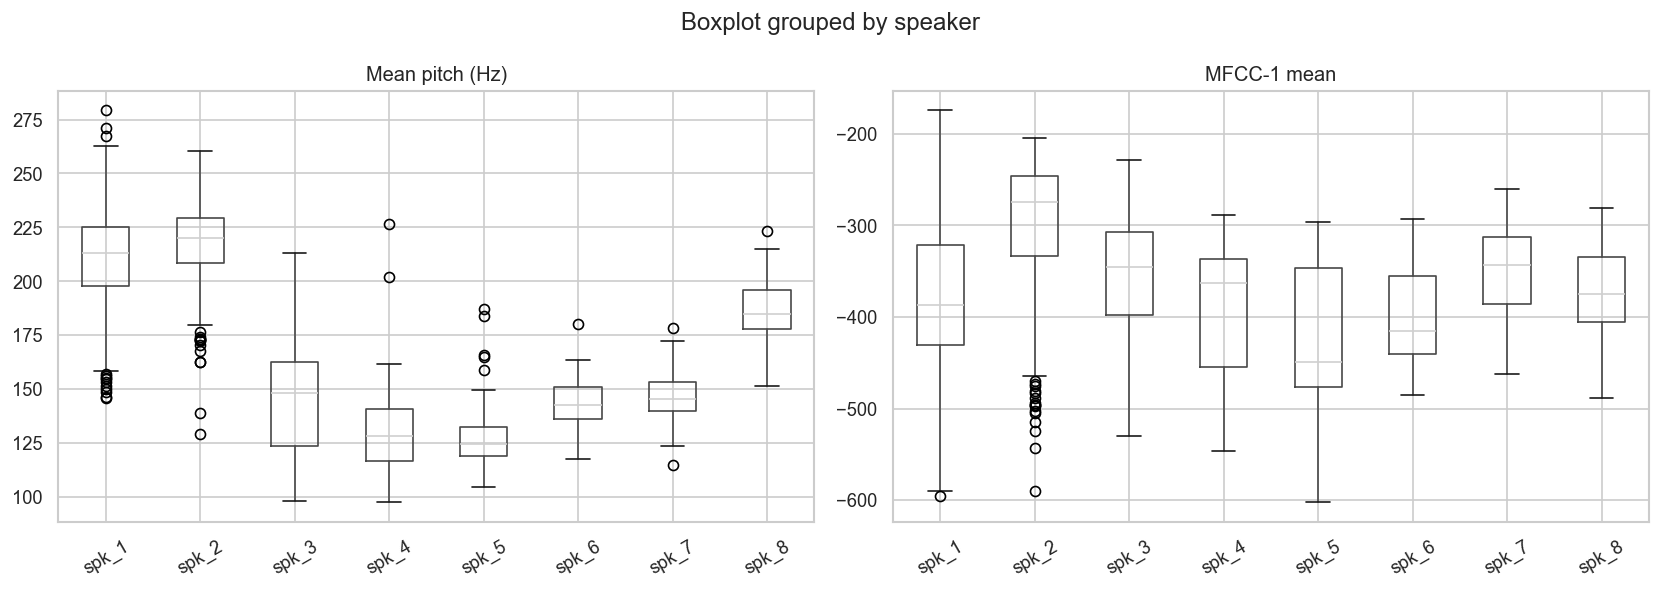

In [9]:
# ── 5b. Within-speaker consistency for pitch & top MFCCs ──────────────────────
# Select 8 speakers with the most clips to make box plots readable
top_speakers = feat_df.groupby("client_id").size().nlargest(8).index
top_spk_short = {s: f"spk_{i+1}" for i, s in enumerate(top_speakers)}

sub = feat_df[feat_df["client_id"].isin(top_speakers)].copy()
sub["speaker"] = sub["client_id"].map(top_spk_short)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Per-speaker spread for top 8 most-recorded speakers", fontsize=13)

sub.boxplot(column="pitch_mean", by="speaker", ax=axes[0])
axes[0].set_title("Mean pitch (Hz)")
axes[0].set_xlabel(""); axes[0].tick_params(axis="x", rotation=30)

sub.boxplot(column="mfcc1_mean", by="speaker", ax=axes[1])
axes[1].set_title("MFCC-1 mean")
axes[1].set_xlabel(""); axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## 6. Dimensionality Reduction — Do Speakers Cluster?

PCA and LDA on the full feature vector lets us visually inspect whether speakers form separable clusters — a prerequisite for a verification system.


Using 152 speakers (≥5 clips) — 3390 clip rows


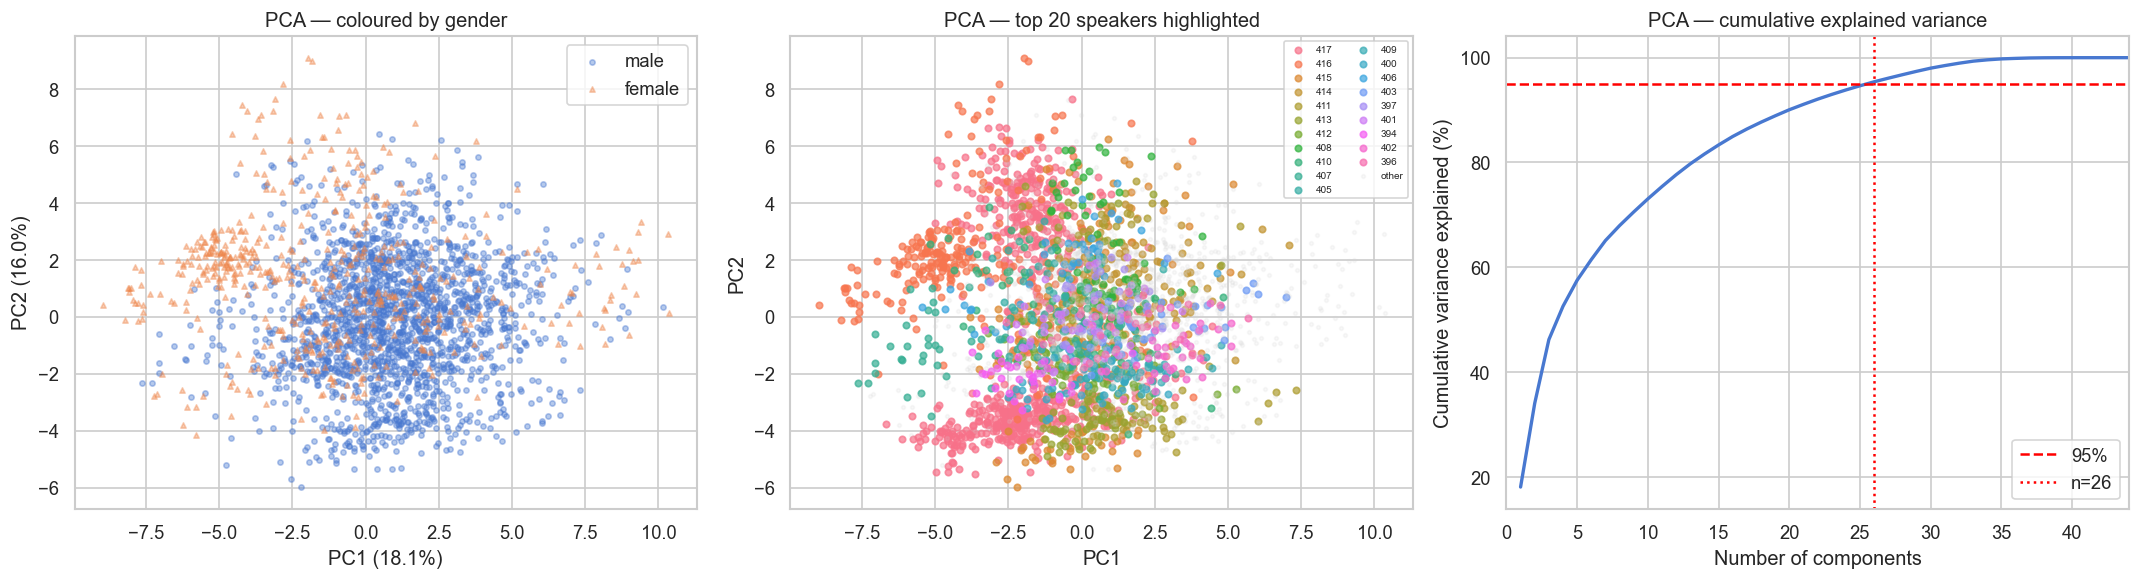

Components needed to explain 95% of variance: 26


In [10]:
# Focus on speakers with ≥5 clips for clarity
SAMPLE_SPKS = 20    # colour only this many speakers; rest greyed out
min_clips_pca = 5

pca_spks = feat_df.groupby("client_id").filter(lambda g: len(g) >= min_clips_pca)
print(f"Using {pca_spks['client_id'].nunique()} speakers (≥{min_clips_pca} clips) "
      f"— {len(pca_spks)} clip rows")

X = pca_spks[FEAT_COLS].fillna(0).values
y_spk = pca_spks["spk_idx"].values
y_gender = pca_spks["gender"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── PCA ───────────────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Variance explained
pca_full = PCA().fit(X_scaled)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
n_for_95 = int(np.searchsorted(cumvar, 0.95)) + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PC1 vs PC2 coloured by gender
for g, marker in [("male","o"),("female","^")]:
    mask = y_gender == g
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    s=10, alpha=0.4, label=g, marker=marker)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("PCA — coloured by gender")
axes[0].legend()

# PC1 vs PC2 coloured by speaker (top N speakers)
top_spk_idx = pca_spks.groupby("spk_idx").size().nlargest(SAMPLE_SPKS).index.tolist()
palette = sns.color_palette("husl", SAMPLE_SPKS)
for i, (si, col) in enumerate(zip(top_spk_idx, palette)):
    mask = y_spk == si
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    s=15, alpha=0.7, color=col, label=str(si))
other_mask = ~np.isin(y_spk, top_spk_idx)
axes[1].scatter(X_pca[other_mask, 0], X_pca[other_mask, 1],
                s=5, alpha=0.15, color="lightgrey", label="other")
axes[1].set_xlabel(f"PC1"); axes[1].set_ylabel("PC2")
axes[1].set_title(f"PCA — top {SAMPLE_SPKS} speakers highlighted")
axes[1].legend(fontsize=6, ncol=2, loc="best")

# Cumulative explained variance
axes[2].plot(range(1, len(cumvar)+1), cumvar * 100, lw=2)
axes[2].axhline(95, color="red", linestyle="--", label="95%")
axes[2].axvline(n_for_95, color="red", linestyle=":", label=f"n={n_for_95}")
axes[2].set_xlabel("Number of components")
axes[2].set_ylabel("Cumulative variance explained (%)")
axes[2].set_title("PCA — cumulative explained variance")
axes[2].legend()
axes[2].set_xlim(0, min(60, len(cumvar)))

plt.tight_layout()
plt.show()
print(f"Components needed to explain 95% of variance: {n_for_95}")


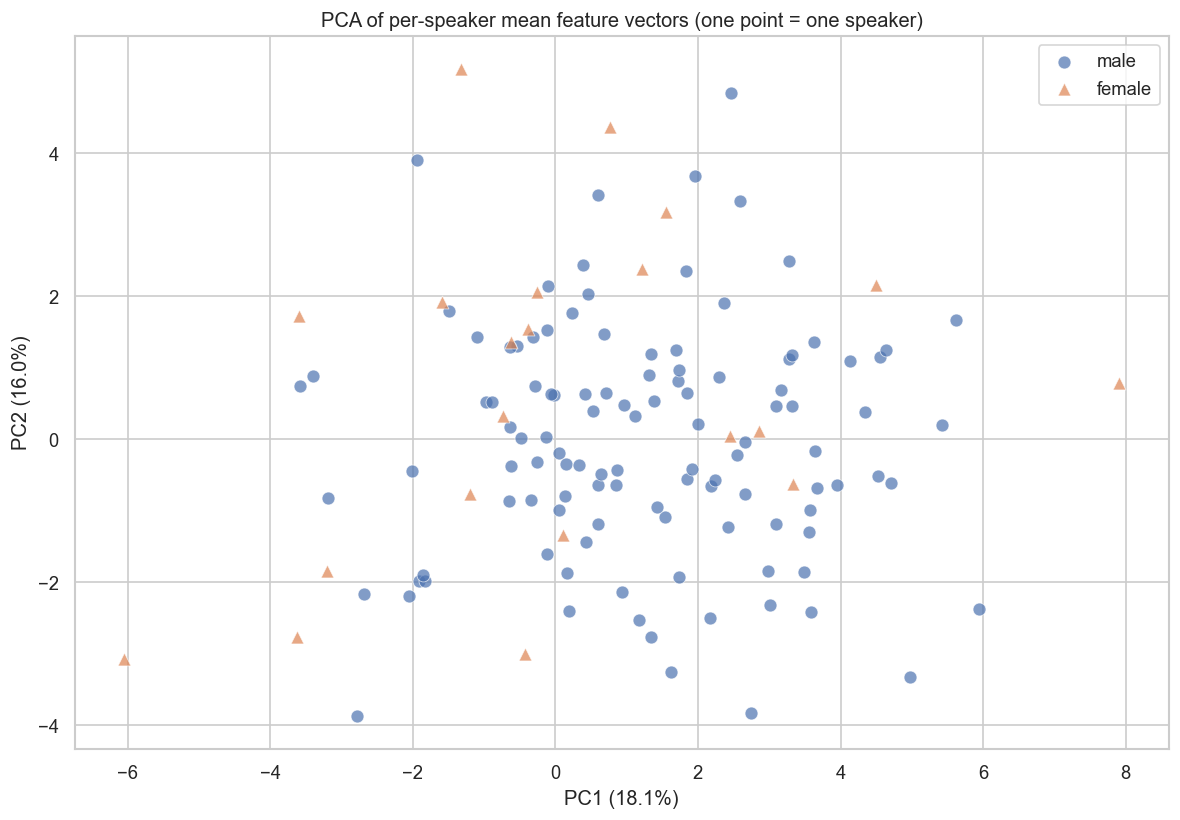

In [11]:
# ── Speaker-mean embeddings: how separable are the centroids? ─────────────────
# Compute per-speaker mean feature vector, then PCA-project
spk_mean_feat = pca_spks.groupby("client_id")[FEAT_COLS].mean().fillna(0)
spk_meta      = pca_spks.drop_duplicates("client_id").set_index("client_id")[["gender", "age", "spk_idx"]]
spk_df        = spk_mean_feat.join(spk_meta)

X_spk_scaled = scaler.transform(spk_df[FEAT_COLS].values)
X_spk_pca    = pca.transform(X_spk_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
for g, marker, col in [("male", "o", "#4C72B0"), ("female", "^", "#DD8452")]:
    mask = spk_df["gender"] == g
    ax.scatter(X_spk_pca[mask, 0], X_spk_pca[mask, 1],
               s=60, alpha=0.7, marker=marker, color=col, label=g, edgecolors="white", lw=0.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA of per-speaker mean feature vectors (one point = one speaker)")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Speaker Verification Baseline — Cosine Similarity Test

A simple but meaningful test: given two clips from the **same** speaker, their feature vectors should be more similar (higher cosine similarity) than two clips from **different** speakers.

We sample same-speaker and different-speaker pairs and plot the cosine similarity distributions. The separation between the two distributions directly indicates how verifiable speakers are with these features.


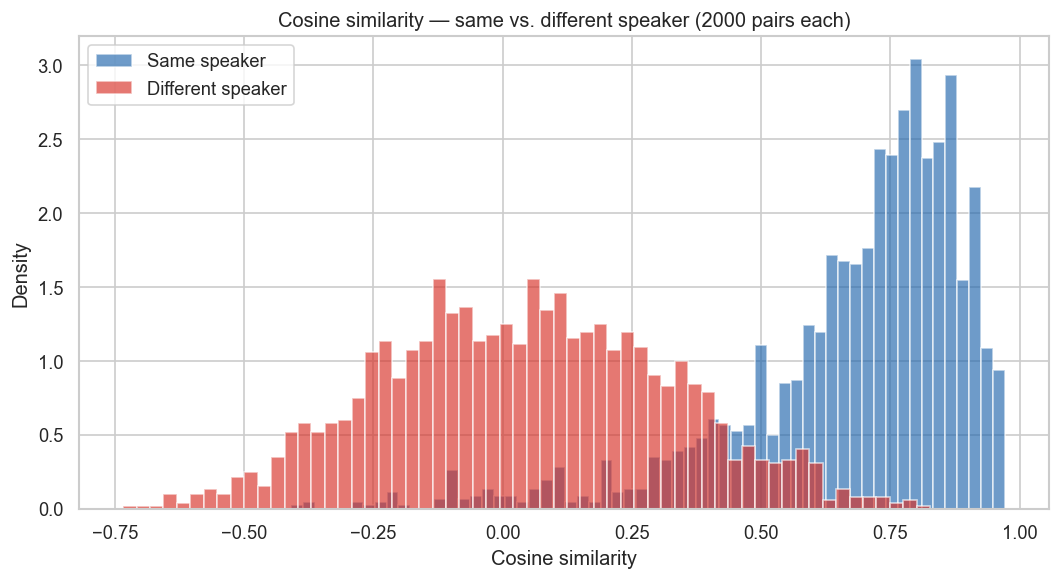

Same-speaker  mean similarity: 0.6802  ±0.2254
Diff-speaker  mean similarity: 0.0446  ±0.2753
Separation (Δmean / pooled std): 2.526  (d')


In [12]:
from sklearn.metrics.pairwise import cosine_similarity

rng = np.random.default_rng(42)
N_PAIRS = 2000

# Pool only speakers with ≥2 clips
pool = feat_df.groupby("client_id").filter(lambda g: len(g) >= 2)
pool_scaled = scaler.transform(pool[FEAT_COLS].fillna(0).values)

spk_groups = {spk: np.where(pool["client_id"].values == spk)[0]
              for spk in pool["client_id"].unique()}
spk_list = list(spk_groups.keys())

same_sims, diff_sims = [], []

for _ in range(N_PAIRS):
    # Same-speaker pair
    spk = rng.choice(spk_list)
    idx = rng.choice(spk_groups[spk], size=2, replace=False)
    same_sims.append(float(cosine_similarity(pool_scaled[[idx[0]]], pool_scaled[[idx[1]]])))

    # Different-speaker pair
    s1, s2 = rng.choice(spk_list, size=2, replace=False)
    i1 = rng.choice(spk_groups[s1])
    i2 = rng.choice(spk_groups[s2])
    diff_sims.append(float(cosine_similarity(pool_scaled[[i1]], pool_scaled[[i2]])))

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(same_sims, bins=60, alpha=0.65, color="#2166ac", density=True, label="Same speaker")
ax.hist(diff_sims, bins=60, alpha=0.65, color="#d73027", density=True, label="Different speaker")
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Density")
ax.set_title(f"Cosine similarity — same vs. different speaker ({N_PAIRS} pairs each)")
ax.legend()
plt.tight_layout()
plt.show()

same_arr = np.array(same_sims)
diff_arr = np.array(diff_sims)
print(f"Same-speaker  mean similarity: {same_arr.mean():.4f}  ±{same_arr.std():.4f}")
print(f"Diff-speaker  mean similarity: {diff_arr.mean():.4f}  ±{diff_arr.std():.4f}")
print(f"Separation (Δmean / pooled std): "
      f"{(same_arr.mean()-diff_arr.mean()) / np.sqrt((same_arr.std()**2+diff_arr.std()**2)/2):.3f}  (d')")


## 8. Summary & Recommendations for a Verification Model

### Key findings from the analysis

| Finding | Implication |
|---|---|
| **MFCCs (especially MFCC 1-6 means)** show the highest F-ratios | These should be the primary features in any verification model |
| **Mean pitch (F0)** is strongly gender-separated and moderately speaker-separated | Useful as a complementary feature; not alone reliable due to within-speaker variability |
| **Spectral centroid & bandwidth** carry moderate discriminative power | Include as secondary features |
| **Voiced ratio** and **ZCR** vary mostly with phonetic content (not speaker) | Low F-ratio — likely not worth including raw |
| PCA shows gender separation in PC1 but limited individual speaker clustering | Raw features are not sufficient alone — embeddings or a neural network are needed |
| Cosine similarity distributions partly overlap | Confirms the need for a learned representation (e.g. x-vector or d-vector) |

### Recommended next steps

1. **Train a speaker encoder** (e.g. LSTM + GE2E loss or ECAPA-TDNN) using the top-F-ratio features as input, producing a fixed-length embedding per utterance.
2. **Enroll** each claimed speaker with 3–5 clips → compute centroid embedding.
3. **Verify** by computing cosine similarity between a new clip's embedding and the enrolled centroid; threshold at an operating point tuned on the held-out split CSV.
4. Consider **i-vector / x-vector** baselines using the `data/commonvoice-v24_en-AU-split.csv` train/dev/test splits.
5. Augment training with noise and speed perturbation to improve robustness.
